In [1]:
from Fit_Bifunzione.Utilities_copy import extract_and_filter_mass

m_25 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH25_LH_2017.root", "Events")
m_50 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH50_LH_2017.root", "Events")
m_75 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH75_LH_2017.root", "Events")
m_100 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH100_LH_2017.root", "Events")
m_125 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH125_LH_2017.root", "Events")
m_150 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH150_LH_2017.root", "Events")
m_175 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH175_LH_2017.root", "Events")
m_200 = extract_and_filter_mass("/home/riccardo/Tesi/Cartella_Analisi_Dati/Dati/Tprime_tAq_1800_MH200_LH_2017.root", "Events")


/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_3201/637816133.py:32: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.hist(massa, bins=50, range=(0,300), histtype="step", linewidth=2, color=colori[i], alpha=1, label=f"$\phi${25+25*i} GeV")


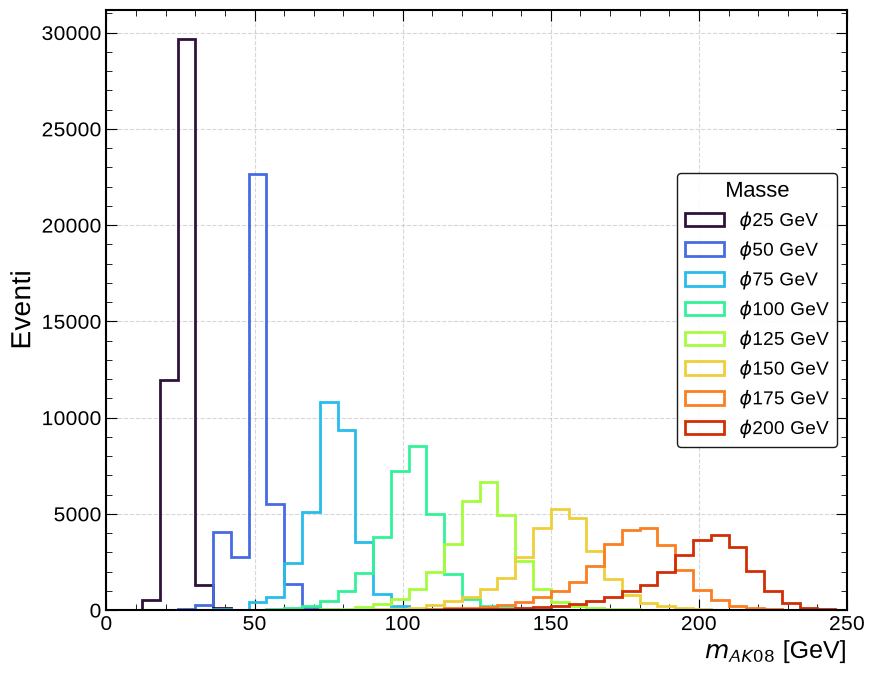

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator

#Qui si configura lo stile dei grafici, in particolare i font e le dimensioni dei tick
plt.rcParams.update({
    'font.size': 15,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.5,
})

#Qui si crea il grafico come oggetto 
fig, ax = plt.subplots(figsize=(9, 7))

lista_masse=[m_25, m_50, m_75, m_100, m_125, m_150, m_175, m_200]

#Qui creaiamo la lista dinamica, potrebbe essere utile in futuro
colori=[plt.cm.turbo(i/len(lista_masse)) for i in range(len(lista_masse))]

#Generiamo i plot in maniera dinamica:
for i, massa in enumerate(lista_masse):
    ax.hist(massa, bins=50, range=(0,300), histtype="step", linewidth=2, color=colori[i], alpha=1, label=f"$\phi${25+25*i} GeV")

#ax.hist(dati_piatti_25, bins=50, range=(0,300), histtype="step", color=colore_MH25, alpha=1, label=r"MH25")
#ax.hist(dati_piatti_50, bins=50, range=(0,300), histtype="step", color=colore_MH50, alpha=1, label=r"MH50")
#ax.hist(dati_piatti_75, bins=50, range=(0,300), histtype="step", color=colore_MH75, alpha=1, label=r"MH75")

# --- 4. FORMATTAZIONE ASSI E TESTI ---
# Asse Y
ax.set_ylabel('Eventi', fontsize=20)
# plt.ylim(0, valore_massimo) # Scommenta e adatta se vuoi fissare l'altezza dell'asse Y

# Asse X: il parametro loc='right' sposta il titolo all'estrema destra (Stile ROOT)
ax.set_xlabel(r'$m_{AK08}$ [GeV]', fontsize=18, loc='right')

# Titolo DENTRO il grafico, in alto a destra
# transform=ax.transAxes usa coordinate relative da 0 a 1 (0.95 = 95% della larghezza/altezza)
#ax.text(0.95, 0.95, 'Plot Masse Higgs', transform=ax.transAxes, fontsize=20, fontweight='bold', ha='right', va='top')

# Legenda: spostata a sinistra per non sovrapporsi al titolo
ax.legend(loc='right', frameon=True, fontsize=14, framealpha=0.9, edgecolor='black', title='Masse', title_fontsize=16)

# Griglia e tick minori (migliorano molto l'aspetto tecnico)
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_ylim(bottom=0)  # Imposta il limite inferiore dell'asse Y a 0
ax.set_xlim(0, 250)  # Imposta i limiti dell'asse X in base ai bin
# --- 5. SALVATAGGIO E MOSTRA ---
plt.tight_layout()
plt.savefig('/home/riccardo/Tesi/Cartella_Analisi_Dati/Immagini/Plot_Totali.png', bbox_inches='tight')
plt.show()

In [3]:
from scipy.interpolate import interp1d
from Fit_Bifunzione.Utilities_copy import voigt2

class DoubleVoigtFit2:
    def __init__(self, mass, fit_values, exclude_mass=50, ax=None, color=None):
        self.mass = mass
        self.ax = ax
        self.color = color
        
        self.param_names = ["norm", "mu", "sigma", "gamma", "norm2", "mu2", "sigma2", "gamma2"]
        
        exclude_key = f"MH{exclude_mass}"
        cleaned_data = {float(k.replace("MH", "")): params for k, params in fit_values.items() if str(k).startswith("MH") and k != exclude_key}

        self.masse = sorted(cleaned_data.keys())

        self.y_params = np.array([[cleaned_data[m][p] for m in self.masse] for p in self.param_names])

    def get_fit_parameters(self):
        interpolator = interp1d(self.masse, self.y_params, kind='linear', fill_value='extrapolate')
        
        interpolated_values = interpolator(self.mass)
        
        return dict(zip(self.param_names, interpolated_values))
    
    def grafico(self):
        fit_params = self.get_fit_parameters()
        x = np.linspace(0, 250, 300)
        
       
        args_for_voigt = [fit_params[p] for p in self.param_names]
        y = voigt2(x, *args_for_voigt)
        plt.rcParams.update({
        'font.size': 12,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Liberation Sans', 'DejaVu Sans'],
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.size': 8,
        'ytick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.minor.size': 4,
        'xtick.top': True,
        'ytick.right': True,
        'axes.linewidth': 1.5,       
        })
        ax = self.ax if self.ax is not None else plt.subplots(figsize=(10, 6))[1]
        
            
        ax.plot(x, y, label=f'Curva Interpolata (Massa {self.mass})', color=self.color)
        ax.set_title(f'Interpolazione per la Massa {self.mass}')
        ax.set_xlabel('Massa')
        ax.set_ylabel('Densità')
        ax.text(0.95, 0.95, 'Plot Masse Higgs', transform=ax.transAxes, 
            fontsize=14, fontweight='bold', ha='right', va='top')
        ax.legend()
        ax.grid(True)

